In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
copy_number_inference = lazy_import("copy_number_inference",os.path.join(utils_dir, "copy_number_inference.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors
from anndata_utils import marker_genes_for_cell_group, get_gene, get_genes, annotate_groups
from gene_signatures_utils import toupper, attach_selected_signatures


In [ ]:
from sklearn.preprocessing import StandardScaler
def standardize_df(df, by_columns = True):
    if not by_columns:
        df = df.T.copy()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)
    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
    if not by_columns:
        scaled_df = scaled_df.T
    scaled_df.index = df.index
    return(scaled_df)
    
def append_frequency_to_string(vector):
    frequency_map = pd.Series(vector).value_counts()
    new_vector = [x + ' (n=' + str(frequency_map.loc[x]) + ')' for x in vector]
    return(new_vector)

def zscore_with_subset(adata, selected_cells):
    mean_val = np.ravel(adata[selected_cells,:].X.mean(axis=0))
    std_val = np.ravel(np.std(adata[selected_cells,:].X.todense(), axis=0))
    adata = adata[:,std_val > 0].copy()
    mean_val = np.ravel(adata[selected_cells,:].X.mean(axis=0))
    std_val = np.ravel(np.std(adata[selected_cells,:].X.todense(), axis=0))
    X = adata.X.todense()
    zscore = np.divide(np.subtract(X, mean_val), std_val)
    adata.layers['zscore_subcells'] = zscore.copy()
    return(adata)

Import data matrices

In [ ]:
adata = sc.read_h5ad("../data/GoL_RNA_normalized__integrated.h5ad")

Feature selection

In [ ]:
subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Epithelial')
valid_genes_0 = (adata[subcells,:].X > 0).sum(axis=0) >= 20
subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] != 'Epithelial')
valid_genes_1 = (adata[subcells,:].X > 0).sum(axis=0) >= 20
subcells = adata.obs['DiseaseState'] == 'Tumor'
valid_genes_2 = (adata[subcells,:].X > 0).sum(axis=0) >= 20
valid_genes = (valid_genes_0) | (valid_genes_1) | (valid_genes_2)

In [ ]:
adata = adata[:,valid_genes].copy()

Exclude adjacent normal samples and acinar cells from PDAC donors

In [ ]:
adata = adata[adata.obs['DiseaseState'] != 'AdjNormal',:].copy()
adata = adata[np.logical_not(np.logical_and(adata.obs['DiseaseState'] == 'Tumor', adata.obs['cell_types'] == 'Acinar')),:].copy()

Conduct phenograph clusters and project Amhed's signatures

In [ ]:
pheno_filename = '../data/GoL_RNA_normalized__clustering.csv'
if not os.path.exists(pheno_filename):
    subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Epithelial')
    adata_sub = adata[subcells,:].copy()
    communities = sc.external.tl.phenograph(adata_sub, k=10, copy=True, clustering_algo = 'leiden', seed = 100)
    adata_sub.obs['pheno_10'] = pd.Categorical(['pheno_' + str(x) for x in communities[0].copy()])
    communities = sc.external.tl.phenograph(adata_sub, k=30, copy=True, clustering_algo = 'leiden', seed = 100)
    adata_sub.obs['pheno_30'] = pd.Categorical(['pheno_' + str(x) for x in communities[0].copy()])
    pheno_10 = np.array(['pheno_other'] * adata.n_obs, dtype=object)
    pheno_10[subcells] = adata_sub.obs['pheno_10'].to_numpy()
    pheno_30 = np.array(['pheno_other'] * adata.n_obs, dtype=object)
    pheno_30[subcells] = adata_sub.obs['pheno_30'].to_numpy()
    adata.obs['pheno_10'] = pheno_10.copy()
    adata.obs['pheno_30'] = pheno_30.copy()
    adata.obs[['pheno_10', 'pheno_30']].to_csv(pheno_filename)
else:
    df = pd.read_csv(pheno_filename, index_col=0)
    df = df.loc[adata.obs_names,:].copy()
    adata.obs['pheno_10'] = df['pheno_10'].to_numpy()
    adata.obs['pheno_30'] = df['pheno_30'].to_numpy()

In [ ]:
subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Epithelial')
adata_sub = adata[subcells,:].copy()


Update cell type annotations in main adata object

In [ ]:
cell_type_refined = np.array(['unknown'] * adata.n_obs, dtype = object)
cell_type_refined[ismember(adata.obs_names, adata_sub.obs_names)[1]] = adata_sub.obs['pheno_30'].to_numpy()
cell_type_refined[adata.obs['cell_types'] == 'Acinar'] = 'acinar'
cell_type_refined[adata.obs['DiseaseState'] == 'Tumor'] = 'tumor'

#cell_type_refined = append_frequency_to_string(cell_type_refined)

adata.obs['cell_type_refined'] = cell_type_refined.copy()

Phenograph clusters 11 and 19 are hard coded as progenitor-like based on preprocessed results

In [ ]:
cell_type_simple = adata.obs['cell_type_refined'].to_numpy().copy()
cell_type_simple[ismember(cell_type_simple, ['pheno_11', 'pheno_19'])[1]] = 'progenitor-like'
cell_type_simple[np.array([x.startswith('pheno') for x in cell_type_simple])] = 'ADM/duct'
adata.obs['cell_type_simple'] = cell_type_simple.copy()

In [ ]:
selected_columns = [
    'progenitor_specific_0',
    'TP53_activity', 'FisherOncogeneTable2_processed', 'BiegingRolett_p53_TSAG_bound',
    'Cdkn2a_canonical', 'David_Smad4_dependent_tgfb_response','TASDEMIR_Senescence_UP',
    'Vallejo_KRAS_8genes', 'DAC_Kras_vs_ADM_UP_T3_vs_T2', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'WARBURG_Brinda', 'KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION'
]

Compute signatures using average z-scores

In [ ]:
signature_df = pd.read_csv('../signatures/GoL_compiled_signatures_human.csv', index_col = 0)

In [ ]:
reference_cells = np.logical_and(adata.obs['cell_types'] == 'Epithelial', adata.obs['DiseaseState'] == 'Healthy')
adata_temp = zscore_with_subset(adata, reference_cells)
adata_temp.layers['zscore'] = adata_temp.layers['zscore_subcells'].copy()

In [ ]:
selected_genes = ['MSN', 'ITGA2', 'ITGA5', 'KRT17', 'HMGA1', 'HMGA2', 'DUSP4', 'DUSP6', 'PHLDA1', 'LAMB3', 'VIM', 'EMP3', 'FSTL3', 'LDHA', 'HK1', 'PKM', 'TGFB2', 'CXCL6', 'CXCL8', 'LIF', 'PLAUR', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'CDKN2A', 'CDKN2B', 'SKIL', 'CLDN4', 'SERPINE1']
temp = pd.DataFrame(adata_temp[:,selected_genes].layers['zscore'])
temp.index = adata.obs_names
temp.columns = selected_genes

df = pd.concat((df, temp), axis=1)

In [ ]:
unique_signatures = np.unique(signature_df['signature_name'])
for my_signature in unique_signatures:
    valid_genes = signature_df['gene_id'][signature_df['signature_name'] == my_signature].to_numpy()
    gene_filter = ismember(adata_temp.var_names, valid_genes)[1]
    adata_temp.var[my_signature] = gene_filter.copy()
    adata_temp.obs[my_signature] = np.ravel(adata_temp[:,gene_filter].layers['zscore'].mean(axis=1))


In [ ]:
df = adata_temp.obs[unique_signatures].copy()
df['TP53_activity'] = adata.obs['TP53_activity'].copy()
#df = pd.concat((df, temp), axis=1)


In [ ]:
selected_columns_average = [
    'progenitor_specific_0',
    'Vallejo_KRAS_8genes',
    'DAC_Kras_vs_ADM_UP_T3_vs_T2',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'WARBURG_Brinda',
]

selected_columns_average = [
    'progenitor_specific_0',
    'DAC_Kras_vs_ADM_UP_T3_vs_T2',
]

In [ ]:
df_temp = df.copy()
df_temp['cell_type_refined'] = adata_temp.obs['cell_type_refined'].copy()
df_summary = df_temp.groupby('cell_type_refined').agg('mean')
df_summary = df_summary.loc[:,selected_columns].copy()

df_sub = df_summary.loc[np.logical_not(ismember(df_summary.index, ['tumor', 'acinar'])[1]),:].copy()
ordering = np.argsort(df_sub.loc[:,selected_columns_average].mean(axis=1))
df_sub = df_sub.iloc[ordering,:].copy()
ordered_rows = ['acinar'] + df_sub.index.to_list() + ['tumor']

df_summary = df_summary.loc[ordered_rows,:].copy()

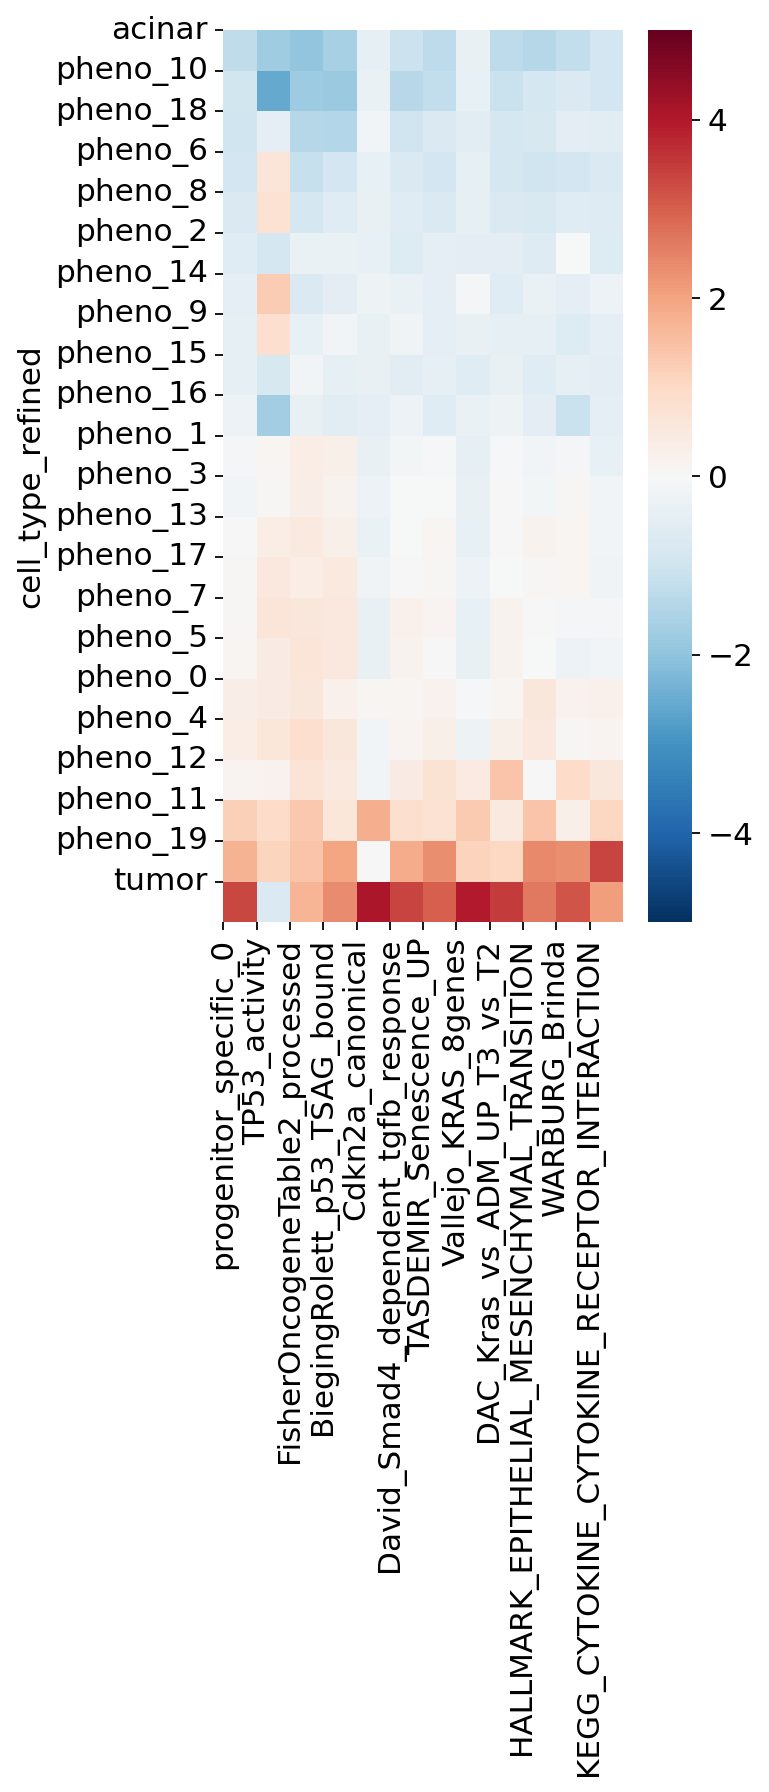

In [ ]:
plt.figure(figsize = [x/3 for x in df_summary.shape[::-1]])
sns.heatmap(standardize_df(df_summary), vmin=-5, vmax= 5, cmap='RdBu_r')
plt.grid(False)
_ = plt.yticks(range(df_summary.shape[0]), labels = df_summary.index.to_numpy())
_ = plt.xticks(range(df_summary.shape[1]), labels = df_summary.columns.to_numpy(), rotation = 90)

Project progenitor score on UMAP

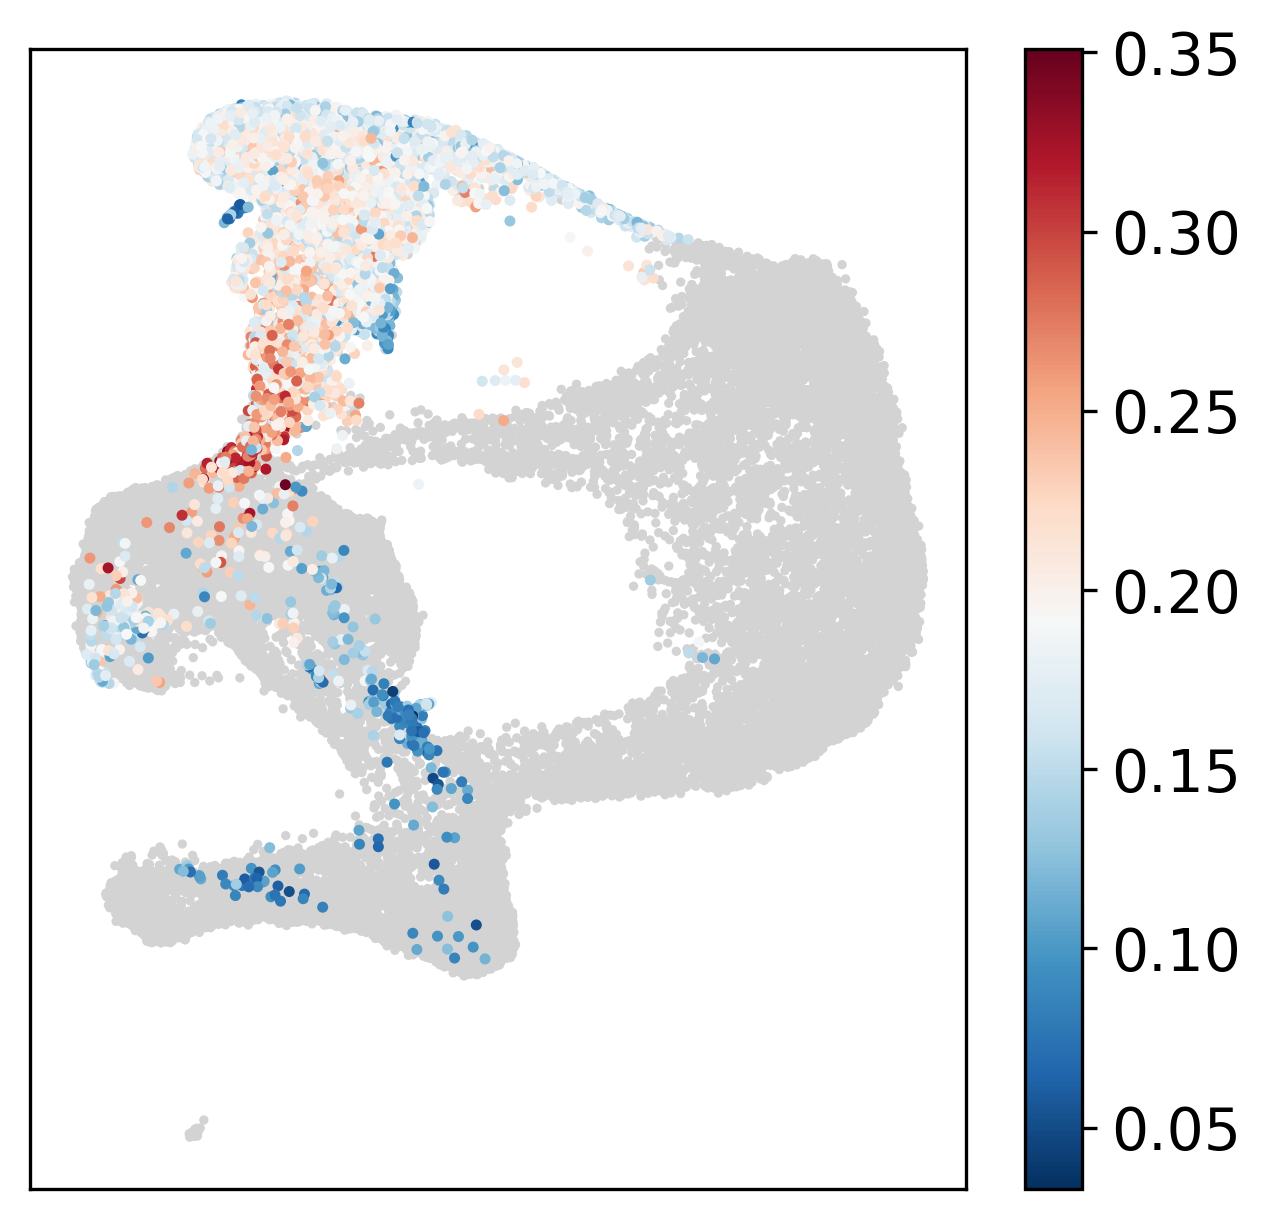

In [ ]:
ax = plot_individual_category(adata, "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, frameon=False)

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Acinar')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='lightgray')

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Tumor', adata.obs['cell_types'] == 'Epithelial')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='darkgray')

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Epithelial')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=True, s = 1, figsize_max=5, scale_3 = 25, scale_2 = 12, ax = ax, background_color='white')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='lightgray')

xval = adata.obsm['X_umap'][subcells,0]
yval = adata.obsm['X_umap'][subcells,1]
c = adata.obs['progenitor_AUCell'].to_numpy()[subcells]
plt.scatter(xval,yval, s=7, edgecolor='none', c = c, cmap='RdBu_r', rasterized = True)
plt.colorbar()


### Plot human umap

In [ ]:
def get_custom_legend_patches(condition_colors, selected_values):
    import matplotlib.patches as mpatches
    patchList = []
    for color, value in zip(condition_colors, selected_values):
        data_key = mpatches.Patch(facecolor=color, label=value, edgecolor='k')
        patchList.append(data_key)
    return(patchList)


In [ ]:
np.unique(adata.obs['patient_id'])

array(['1253', '1261', '1262', '1294', '1296', '1299', '1302', '1306',
       '1307', '1314', '181429', '3210', '4770', '4830', '6750',
       'Donor_1', 'Donor_2', 'Donor_4', 'Donor_5', 'Donor_8', 'Donor_9'],
      dtype=object)

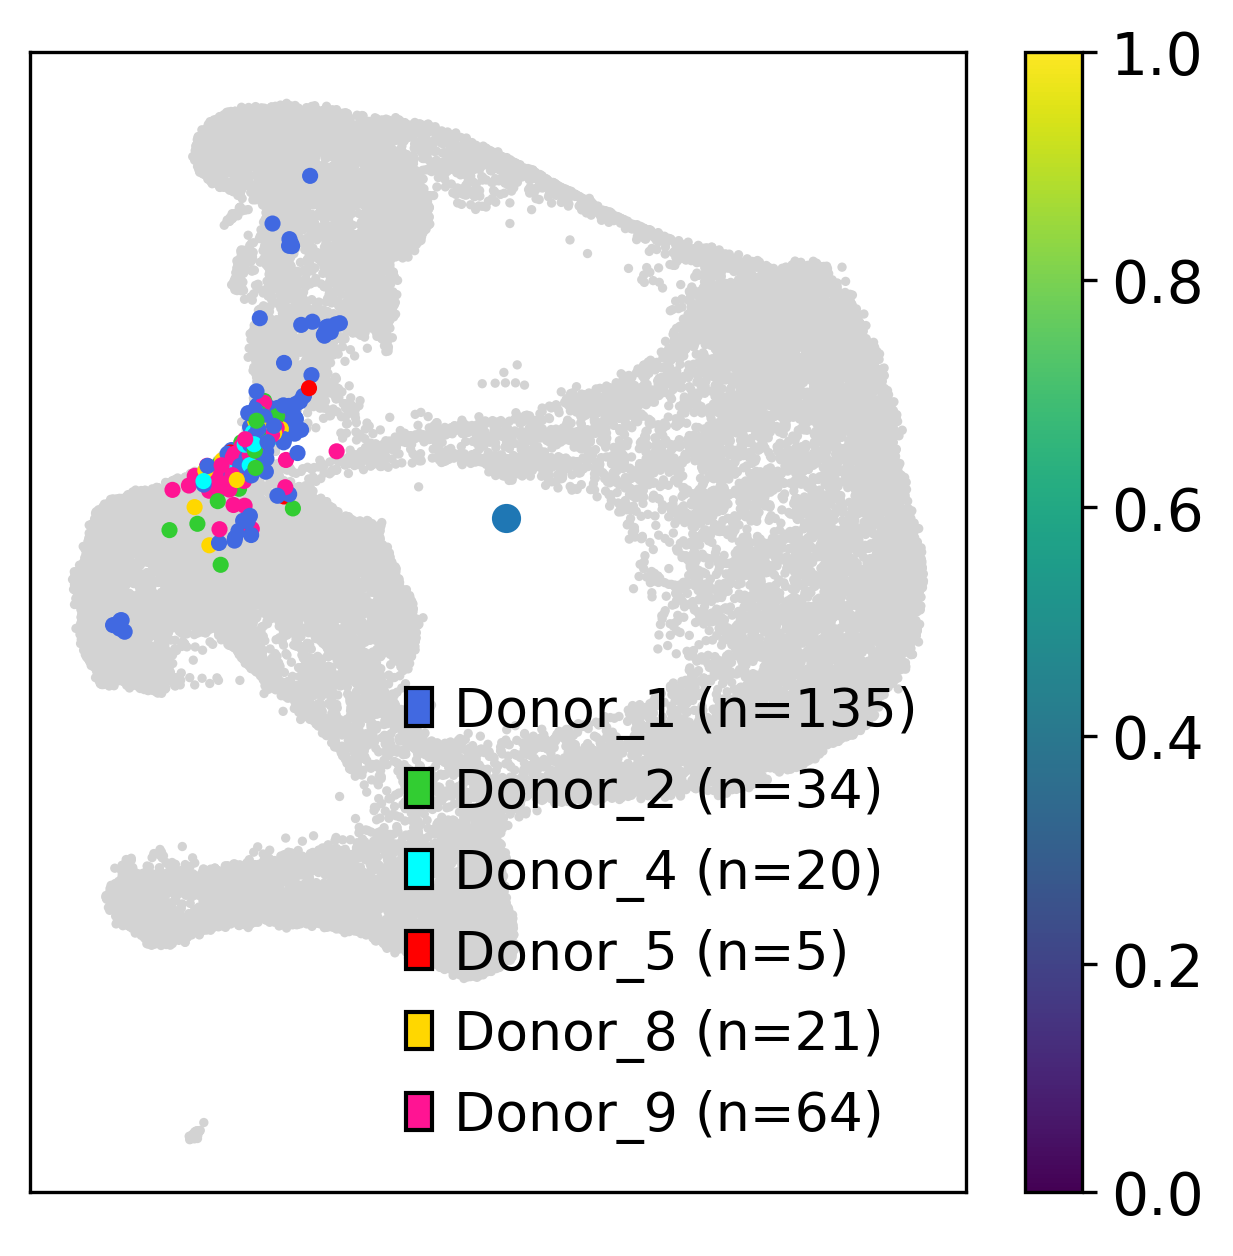

In [ ]:
ax = plot_individual_category(adata, "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, frameon=False)

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Acinar')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='lightgray')

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Tumor', adata.obs['cell_types'] == 'Epithelial')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='darkgray')

subcells = np.logical_and(adata.obs['DiseaseState'] == 'Healthy', adata.obs['cell_types'] == 'Epithelial')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=True, s = 1, figsize_max=5, scale_3 = 25, scale_2 = 12, ax = ax, background_color='white')
ax = plot_individual_category(adata[subcells,:], "X_umap", "cell_types", [], [], use_outlines=False, s = 1, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='lightgray')

subcells = ismember(adata.obs['cell_type_refined'], ['pheno_11', 'pheno_19'])[1]
selected_patients = ['Donor_1', 'Donor_2', 'Donor_4', 'Donor_5', 'Donor_8', 'Donor_9']
selected_colors = ['royalblue', 'limegreen', 'cyan', 'red', 'gold', 'deeppink']
ax = plot_individual_category(adata[subcells,:], "X_umap", "patient_id", selected_patients, selected_colors, use_outlines=False, s = 3, figsize_max=5, scale_3 = 20, scale_2 = 15, ax = ax, background_color='lightgray')

donor_count = adata.obs['patient_id'][np.logical_and(subcells, adata.obs['DiseaseState'] == 'Healthy')].value_counts()
patient_labels = [x + ' (n=' + str(donor_count.loc[x]) + ')' for x in selected_patients]
patches = get_custom_legend_patches(selected_colors, patient_labels)
plt.legend(handles = patches, frameon=False)
plt.scatter(1,1)
plt.colorbar()